# BANK-CUSTOMER-CHURN


   This project focuses on bank customer churn,which occurs when customers stop using a bank's services. By analyzing behavioral and demographic data,the project aim to identify the key factors that drive a customer to leave (churn) versus those who stay. 

   The dataset consists of 10,000 records with the following features:
Demographics: Surname,Geography (Location),Gender,and Age.
Account Details: Tenure (Years with the bank),Balance,NumOfProducts (Number of accounts/services),and EstimatedSalary.
Behavioral Indicators: CreditScore,HasCrCard (Credit card holder),and IsActiveMember.
Target Variable: Exited(Whether the customer churned). 

  The goal is to build a predictive model that helps the bank proactively identify "at-risk" customers and develop retention strategies to improve long-term loyalty.

### 1. DATA LOADING

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action="ignore",category=FutureWarning)
df=pd.read_csv(r"C:\Users\rukku\Downloads\Bank_Churn_Raw.csv")
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619.0,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608.0,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,NaN,France,Female,42,8,159660.80,3,1,0,NaN,1
3,15701354,Boni,699.0,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850.0,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771.0,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516.0,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709.0,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772.0,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


### 2. INITIAL OVERVIEW OF DATASET

#### Basic Structure:

In [14]:
print("Column names of the dataset:",df.columns,"\n")
print("First 5 rows:\n",df.head(),"\n")
print("Last 5 rows:\n",df.tail(),"\n")
print("Shape of the dataset:\n",df.shape,"\n")

Column names of the dataset: Index(['CustomerId', 'LastName', 'CreditScore', 'Country', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Churned', 'Churn_Label'],
      dtype='object') 

First 5 rows:
    CustomerId  LastName  CreditScore Country  Gender  Age  Tenure    Balance  \
0    15634602  Hargrave        619.0  France  Female   42       2       0.00   
1    15647311      Hill        608.0   Spain  Female   41       1   83807.86   
2    15619304      Onio          NaN  France  Female   42       8  159660.80   
3    15701354      Boni        699.0  France  Female   39       1       0.00   
4    15737888  Mitchell        850.0   Spain  Female   43       2  125510.82   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Churned  \
0              1          1               1        101348.88        1   
1              1          0               1        112542.58        0   
2              3          1

In [13]:
print("Structure of the dataset:\n",df.info,"\n")
print("Analytics of the dataset:\n",df.describe().round(2),"\n")
print("Data Types:\n",df.dtypes,"\n")

Structure of the dataset:
 <bound method DataFrame.info of       CustomerId   LastName  CreditScore  Country  Gender  Age  Tenure  \
0       15634602   Hargrave        619.0   France  Female   42       2   
1       15647311       Hill        608.0    Spain  Female   41       1   
2       15619304       Onio          NaN   France  Female   42       8   
3       15701354       Boni        699.0   France  Female   39       1   
4       15737888   Mitchell        850.0    Spain  Female   43       2   
...          ...        ...          ...      ...     ...  ...     ...   
9995    15606229   Obijiaku        771.0   France    Male   39       5   
9996    15569892  Johnstone        516.0   France    Male   35      10   
9997    15584532        Liu        709.0   France  Female   36       7   
9998    15682355  Sabbatini        772.0  Germany    Male   42       3   
9999    15628319     Walker        792.0   France  Female   28       4   

        Balance  NumOfProducts  HasCrCard  IsActiveM

 * Column names,Shape,Analytics,Structure and Data types of the Data set is reviewed.

### 3. DATA PREPROCESSING

#### -> Data cleaning:

In [37]:
df.isnull().sum()   #Check for NULL values

CustomerId          0
Surname             0
CreditScore        12
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
EstimatedSalary    14
Exited              0
dtype: int64

* The dataset is showing NULL data in two columns- CreditScore,EstimatedSalary
* Replace the NULL values with mean() of the respective columns.

#### -> NULL Data handling:

In [5]:
df["CreditScore"].fillna(df["CreditScore"].mean(),inplace=True)
df["EstimatedSalary"].fillna(df["EstimatedSalary"].mean(),inplace=True) 
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### ->Duplicate value handling:

In [15]:
df.duplicated().sum()

np.int64(0)

* The data set shows no duplicate values.

#### -> Column Renaming:

In [2]:
df.rename(columns={"Surname":"LastName"},inplace=True)
df.rename(columns={"Geography":"Country"},inplace=True)
df.rename(columns={"Exited":"Churned"},inplace=True)
print("Column Names:\n",df.columns,"\n")
df

Column Names:
 Index(['CustomerId', 'LastName', 'CreditScore', 'Country', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Churned'],
      dtype='object') 



,CustomerId,LastName,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned
0,15634602,Hargrave,619.0,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608.0,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,NaN,France,Female,42,8,159660.80,3,1,0,NaN,1
3,15701354,Boni,699.0,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850.0,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771.0,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516.0,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709.0,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772.0,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


* The data is cleaned by handling NULL valus,Duplicate values and making changes to the column names. 
* Data is ready for Analysis and Visualizations.

#### -> Derived Columns:

In [10]:
df["BalanceSalaryRatio"]=df["Balance"] / df["EstimatedSalary"]
#This column captures how the balance compares to the estimated salary, which may indicate financial habits.
df["TenureByAge"]=df["Tenure"] / df["Age"]
#This column help standardize tenure over age, indicating loyalty relative to the customer's life stage.
df["IsSenior"]=(df["Age"] > 50).astype(int)
#Create 'IsSenior' column (Binary: 1 if age > 50, 0 otherwise)
df

,CustomerId,LastName,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churned,BalanceSalaryRatio,TenureByAge,IsSenior
0,15634602,Hargrave,619.000000,France,Female,42,2,0.00,1,1,1,101348.880000,1,0.000000,0.047619,0
1,15647311,Hill,608.000000,Spain,Female,41,1,83807.86,1,0,1,112542.580000,0,0.744677,0.024390,0
2,15619304,Onio,650.517221,France,Female,42,8,159660.80,3,1,0,100100.023999,1,1.595013,0.190476,0
3,15701354,Boni,699.000000,France,Female,39,1,0.00,2,0,0,93826.630000,0,0.000000,0.025641,0
4,15737888,Mitchell,850.000000,Spain,Female,43,2,125510.82,1,1,1,79084.100000,0,1.587055,0.046512,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771.000000,France,Male,39,5,0.00,2,1,0,96270.640000,0,0.000000,0.128205,0
9996,15569892,Johnstone,516.000000,France,Male,35,10,57369.61,1,1,1,101699.770000,0,0.564108,0.285714,0
9997,15584532,Liu,709.000000,France,Female,36,7,0.00,1,0,1,42085.580000,1,0.000000,0.194444,0
9998,15682355,Sabbatini,772.000000,Germany,Male,42,3,75075.31,2,1,0,92888.520000,1,0.808230,0.071429,0


### 4. EDA(Exploratory Data Analysis)

#### ->GroupBY:

In [9]:
geo_stats=df.groupby("Country").mean(numeric_only=True).round(2)
print("Country by Numeric coumns:\n",geo_stats,"\n")
# Group by Country and find the mean for numeric columns

churn_by_segment = df.groupby(["Country","Gender"])["Churned"].mean().round(2).reset_index()
print("Churn rate by Country and Gender:\n",churn_by_segment,"\n")
# Churn rate by Country and Gender

segment_churn = df.groupby(["NumOfProducts","IsActiveMember"])["Churned"].mean().round(2)
print("Active vs Inactive Customers by Product count:\n",segment_churn,"\n")
# Churn rate for Active vs Inactive members, segmented by Product Count

top_balances=df[(df["Gender"] =="Female")&(df["IsActiveMember"] == 0)].groupby("Country")["Balance"].max().round(2)
print("Max balance of Not active female customers by country:\n",top_balances,"\n")
# Max balance for female customers who are NOT active members, by Country


Country by Numeric coumns:
           CustomerId  CreditScore    Age  Tenure    Balance  NumOfProducts  \
Country                                                                      
France   15690650.11       649.58  38.51    5.00   62092.64           1.53   
Germany  15690555.65       651.58  39.77    5.01  119730.12           1.52   
Spain    15691918.41       651.34  38.89    5.03   61818.15           1.54   

         HasCrCard  IsActiveMember  EstimatedSalary  Churned  
Country                                                       
France        0.71            0.52         99868.57     0.16  
Germany       0.71            0.50        101183.23     0.32  
Spain         0.69            0.53         99472.38     0.17   

Churn rate by Country and Gender:
    Country  Gender  Churned
0   France  Female     0.20
1   France    Male     0.13
2  Germany  Female     0.38
3  Germany    Male     0.28
4    Spain  Female     0.21
5    Spain    Male     0.13 

Active vs Inactive Customers by

#### ->Pivot Table:

In [10]:
# 1.Churn Rate by Geography and Gender
#This pivot table shows the average churn rate (from the Churned column) for each country, further broken down by gender.
pivot_churn=df.pivot_table(
                            index="Country", 
                            columns="Gender", 
                            values="Churned", 
                            aggfunc="mean"
                          ).round(2)
print("Churn Rate by Geography and Gender:\n",pivot_churn,"\n")

#2. Financial Summary by Active Status
#Use this to compare the average Balance and EstimatedSalary between active and inactive members.
pivot_financials=df.pivot_table(
                                index="IsActiveMember", 
                                values=["Balance","EstimatedSalary"], 
                                aggfunc="mean"
                                ).round(2)
print("Financial Summary by Active Status:\n",pivot_financials,"\n")

#3.Customer Count by Products and Churn
#This table helps visualize the "Product Paradox"—how the number of products a customer holds relates to whether they stay or leave.
pivot_products = df.pivot_table(
                                index="NumOfProducts", 
                                columns="Churned", 
                                values="CustomerId", 
                                aggfunc="count", 
                                fill_value=0
                               ).round(2)
print("Customer Count by Products and Churn:\n",pivot_products,"\n")

Churn Rate by Geography and Gender:
 Gender   Female  Male
Country              
France     0.20  0.13
Germany    0.38  0.28
Spain      0.21  0.13 

Financial Summary by Active Status:
                  Balance  EstimatedSalary
IsActiveMember                           
0               77134.38        100768.54
1               75875.42         99471.01 

Customer Count by Products and Churn:
 Churned           0     1
NumOfProducts            
1              3675  1409
2              4242   348
3                46   220
4                 0    60 



#### -> Statistical Summary:

#### 1. Numerical Column Summary:

In [7]:
#This provides the count,mean,standard deviation,and quartiles for columns like CreditScore,Age,Balance,and EstimatedSalary.
numerical_summary = df.describe().T.round(2)
print(numerical_summary,"\n")

                   count         mean       std          min          25%  \
CustomerId       10000.0  15690940.57  71936.19  15565701.00  15628528.25   
CreditScore      10000.0       650.52     96.56       350.00       584.00   
Age              10000.0        38.92     10.49        18.00        32.00   
Tenure           10000.0         5.01      2.89         0.00         3.00   
Balance          10000.0     76485.89  62397.41         0.00         0.00   
NumOfProducts    10000.0         1.53      0.58         1.00         1.00   
HasCrCard        10000.0         0.71      0.46         0.00         0.00   
IsActiveMember   10000.0         0.52      0.50         0.00         0.00   
EstimatedSalary  10000.0    100100.02  57458.69        11.58     51116.08   
Churned          10000.0         0.20      0.40         0.00         0.00   

                         50%          75%          max  
CustomerId       15690738.00  15753233.75  15815690.00  
CreditScore           652.00       717

Statistical Findings:

* Average Age: Typically around 38–40 years.
* Churn Rate: The mean of the Exited column (often around 0.20) represents the overall percentage of customers who left.
* Zero Balances: A high frequency of 0 in the Balance column is common in this dataset, indicating many customers do not use their accounts as primary savings.

#### 2. Categorical Column Summary:

In [19]:
#For non-numeric data like Country and Gender,use include='object' to see unique counts and the most frequent category.
categorical_summary=df.describe(include=["object"]).T
print(categorical_summary,"\n")

          count unique     top  freq
LastName  10000   2932   Smith    32
Country   10000      3  France  5014
Gender    10000      2    Male  5457 



Statistical Findings:

* Geography: France usually represents the largest portion of the dataset.
* Gender Distribution: Often shows a relatively even split, though some clusters show higher churn among females.

#### 3. Grouped Statistics by Churn:

In [12]:
#Comparing the means of features for those who left vs. those who stayed reveals identifying characteristics of churners.
churn_comparison = df.groupby("Churned").mean(numeric_only=True).round(2)
print(churn_comparison,"\n")

          CustomerId  CreditScore    Age  Tenure   Balance  NumOfProducts  \
Churned                                                                     
0        15691167.88       651.84  37.41    5.03  72745.30           1.54   
1        15690051.96       645.36  44.84    4.93  91108.54           1.48   

         HasCrCard  IsActiveMember  EstimatedSalary  
Churned                                              
0             0.71            0.55         99729.03  
1             0.70            0.36        101552.23   



Statistical Findings:

* Higher Balances: Customers who churn tend to have higher average balances than those who stay, indicating the loss of high-value clients.
* Older Age: Churned customers generally have a higher average age (often 40+) compared to loyalists.

### 5. Visualizations

#### 1. Overall Churn Proportion (Pie Chart):

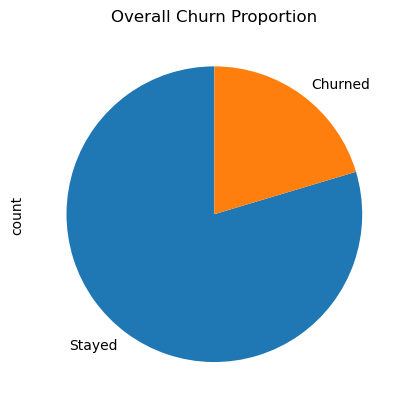

In [4]:
#Shows the balance between customers who stayed vs those who left.
df['Churned'].value_counts().plot.pie(labels=["Stayed","Churned"],startangle=90)
plt.title("Overall Churn Proportion")
plt.show()

* Shows a clear class imbalance. 
* Approximately 20% of the customer base has exited, meaning the bank loses 1 out of every 5 customers.

#### 2. Churn Frequency by Country (Bar Plot):

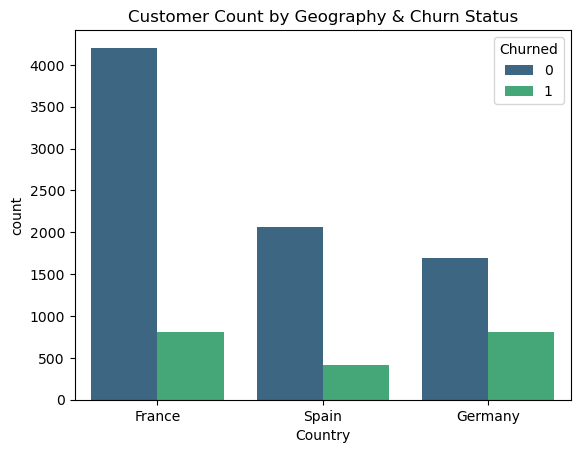

In [10]:
#Identifies which regions have the highest volume of exits.
sns.countplot(data=df,x="Country",hue="Churned",palette="viridis")
plt.title("Customer Count by Geography & Churn Status")
plt.show()

*  France has the highest total number of customers.
*  But Germany shows a significantly higher proportion of churn relative to its size.

#### 3. Age Distribution by Churn (Box Plot):

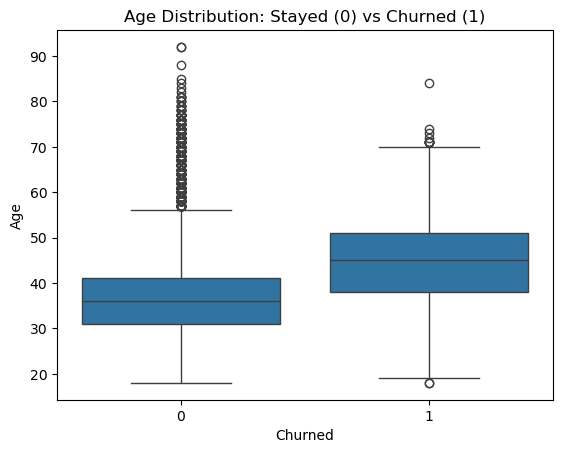

In [10]:
#Visualizes how age significantly impacts the likelihood of churning.
sns.boxplot(data=df,x="Churned",y="Age")
plt.title("Age Distribution: Stayed (0) vs Churned (1)")
plt.show()

* The median age of churned customers is notably higher (mid-40s) than those who stayed (mid-30s).
* Older customers are a higher-risk segment.

#### 4. Feature Correlation Matrix (Heatmap):

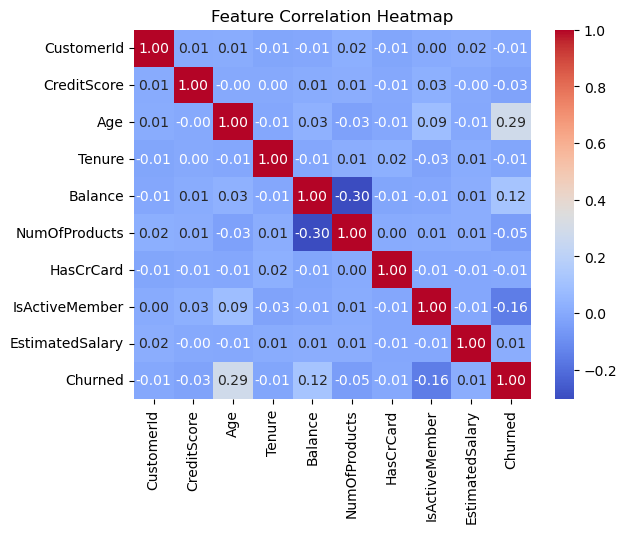

In [11]:
#Reveals linear relationships between all numerical variables.
sns.heatmap(df.select_dtypes(include=["number"]).corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

* Age shows the strongest positive correlation with churn (Exited).
* While IsActiveMember shows the strongest negative correlation.

#### 5. Credit Score Density (Histogram):

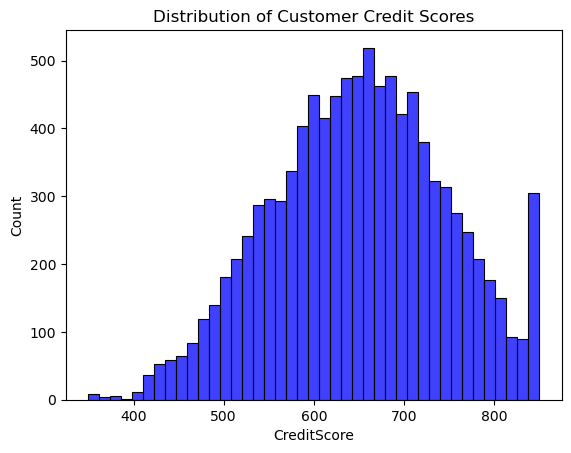

In [5]:
#Shows the distribution of creditworthiness across the entire customer base.
sns.histplot(df["CreditScore"],color="blue")
plt.title("Distribution of Customer Credit Scores")
plt.show()

* Most customers fall in the 600–700 range.
* There is a small spike of churned customers with very low credit scores (below 400).

#### 6. Balance Distribution by Churn (Overlapping Histogram):

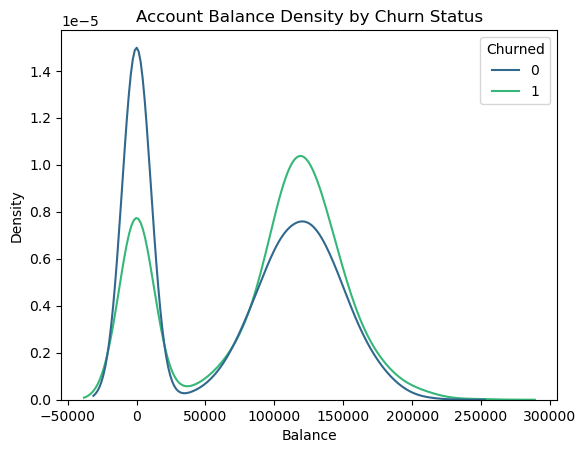

In [8]:
#Compares the account balances of loyalists vs. those who churned.
sns.kdeplot(data=df,x="Balance",hue="Churned",common_norm=False, palette="viridis")
plt.title("Account Balance Density by Churn Status")
plt.show()

* A large group of retained customers has a zero balance.
* Churned customers,however,are more likely to have balances between 100k and 150k.

#### 7. Product Count Impact (Stacked Bar Chart):

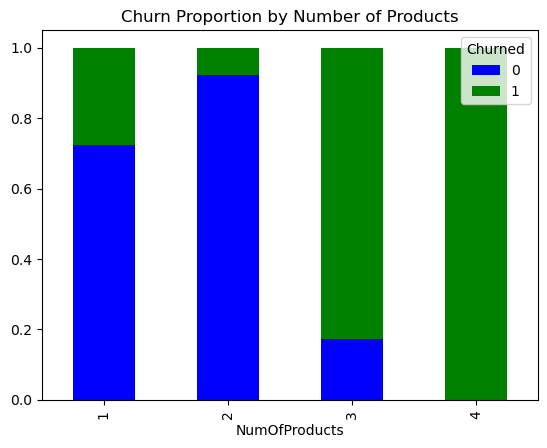

In [33]:
#Visualizes how the number of products relates to churn probability.
prod_churn=pd.crosstab(df["NumOfProducts"],df["Churned"])
prod_churn.div(prod_churn.sum(1),axis=0).plot(kind="bar",stacked=True,color=["blue","green"])
plt.title("Churn Proportion by Number of Products")
plt.show()

* Customers with 3 or 4 products have an extremely high churn rate (nearly 100%).
* While those with 2 products are the most loyal.

#### 8. Gender-wise Churn Analysis (Count Plot):

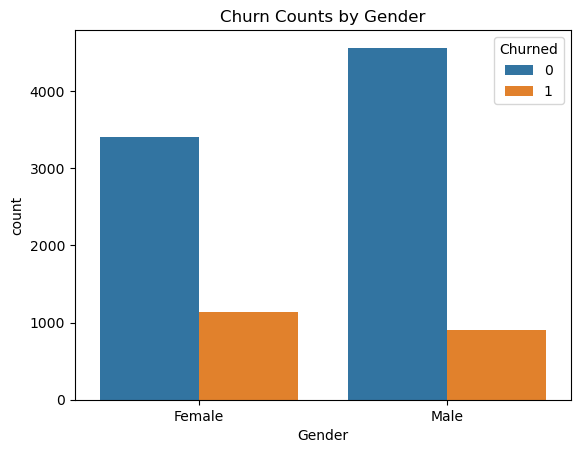

In [21]:
#Compares churn volume across different genders
sns.countplot(data=df,x="Gender",hue="Churned")
plt.title("Churn Counts by Gender")
plt.show()

* Female customers show a higher rate of churn compared to males.
* Indicating a potential need for gender-specific retention strategies.

#### 9. Churn Rate by Tenure (Line Chart):

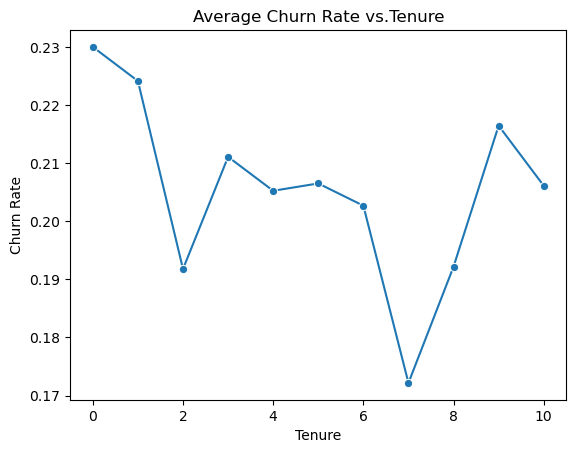

In [8]:
#Shows if customer loyalty (years with the bank) reduces the churn rate
tenure_churn=df.groupby("Tenure")["Churned"].mean()
sns.lineplot(x=tenure_churn.index,y=tenure_churn.values,marker="o")
plt.title("Average Churn Rate vs.Tenure")
plt.ylabel("Churn Rate")
plt.show()

* Significant dip at Tenure 7 (~0.17).
* Churn rate spikes sharply from year 7 to 9.

#### 10. Salary Distribution by Geography (Violin Plot):

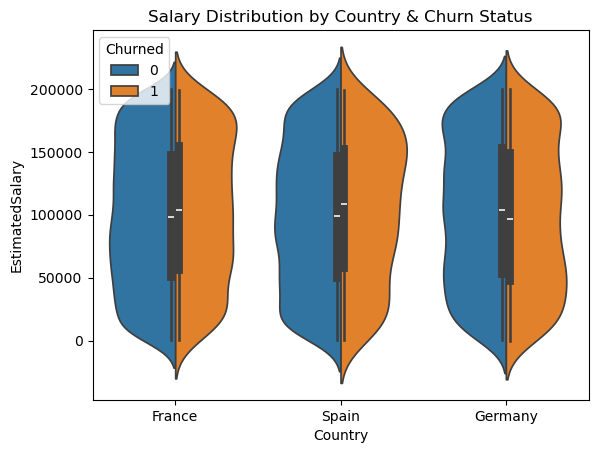

In [24]:
#Shows the spread of salaries across countries and how it varies for churned users
sns.violinplot(data=df,x="Country",y="EstimatedSalary",hue="Churned",split=True)
plt.title("Salary Distribution by Country & Churn Status")
plt.show()

* Salary distributions are remarkably similar across all three countries.
* Suggesting that income level is not a primary driver of regional churn differences.

#### 11. Churn Rate by Credit Card Ownership (Bar Plot):

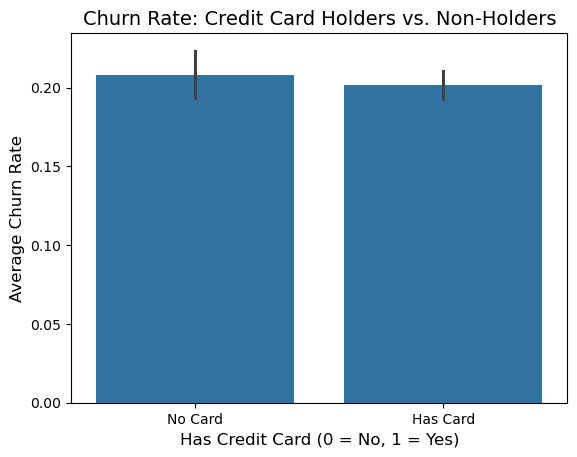

In [25]:
#This chart helps determine if customers with a bank credit card are more or less loyal than those without
sns.barplot(data=df,x="HasCrCard",y="Churned")
plt.title("Churn Rate: Credit Card Holders vs. Non-Holders",fontsize=14)
plt.xlabel("Has Credit Card (0 = No, 1 = Yes)",fontsize=12)
plt.ylabel("Average Churn Rate",fontsize=12)
plt.xticks([0, 1],["No Card","Has Card"])
plt.show()

* Churn rates are nearly identical between those with and without credit cards.
* Suggesting card ownership does not impact loyalty.

#### 12. Churn Trend by Age(Line Plot):

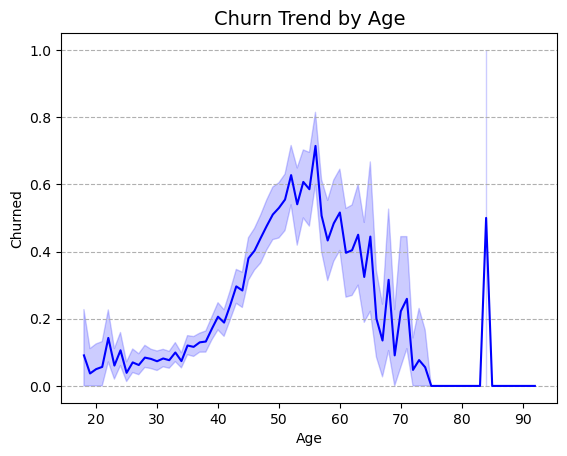

In [26]:
#The relationship between a single factor (Age) and the likelihood of leaving (Churn)
sns.lineplot(data=df,x="Age",y="Churned",color="Blue")
plt.title("Churn Trend by Age",fontsize=14)
plt.grid(axis="y",linestyle="--")
plt.show()

* Churn risk climbs steadily starting at age 35, peaks around age 50–55, and then begins to decline for elderly customers.

#### 13. Hierarchical Churn Breakdown (Sunburst Chart):

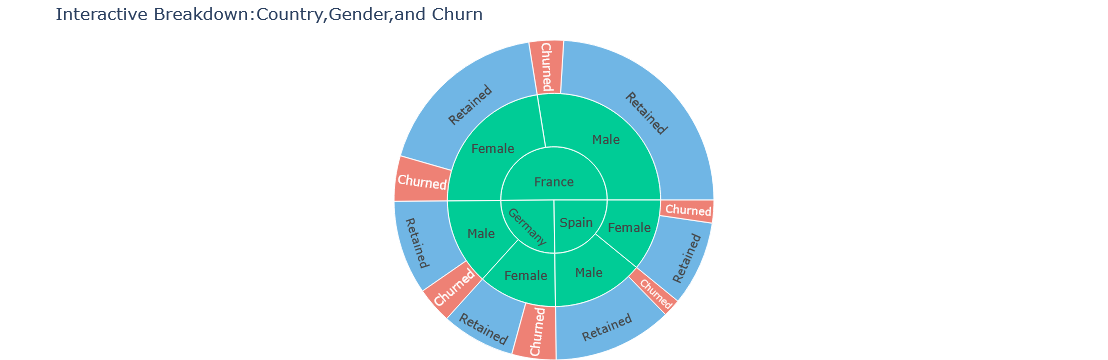

In [13]:
# This interactive chart lets you click on a country to "drill down" into its gender distribution and see
# the churn proportion for each specific subgroup.
df["Churn_Label"]=df["Churned"].map({0:"Retained",1:"Churned"})
fig = px.sunburst(
    df, 
    path=["Country","Gender","Churn_Label"], 
    color="Churn_Label",
    color_discrete_map={"Retained":"#3498db","Churned":"#e74c3c"},
    title="Interactive Breakdown:Country,Gender,and Churn"
)
fig.update_layout(margin=dict(t=40,l=0,r=0,b=0))
fig.show()

* Confirms that Female customers in Germany represent one of the most significant risk segments for the bank.

### KEY INSIGHTS:

### Current Scenario:
   The bank is losing 1 out of every 5 customers (20% churn). The data shows that churn isn't random; it follows specific patterns based on location, age, and how many products a customer uses.
#### * Location Risk: Customers in Germany leave at much higher rates than those in France or Spain.
#### * Age Gap: Older customers (40–55) are much more likely to leave than younger ones.
#### * Product Trap: Having 3 or 4 products leads to nearly 100% churn, while 2 products is the "sweet spot" for loyalty.
#### * Balance Irony: Customers with high balances (100k+) are actually more likely to quit than those with $0 balances.
#### * Gender Gap: Female customers are exiting at a higher rate than males.

### Future Strategies for Better Retention:

#### * Fix the "German Gap": Investigate local competitors in Germany and offer regional loyalty rewards to match.
#### * Target the 40+ Group: Create premium "Legacy" or "Wealth Management" perks for middle-aged customers with high balances.
#### * Optimize Product Sales: Stop pushing for 3+ products. Focus on moving 1-product customers to 2 products to maximize stability.
#### * Re-activate Inactive Members: Use "We Miss You" offers or fee waivers to engage users who haven't used their accounts recently.
#### * Gender-Specific Outreach: Develop financial wellness programs or personalized services tailored to female clients.